Student Number: 40498534
First Name:     SARIHAA
Surname:        SHANMUGASUNDARAM
Module:         ECS8055
Submission Date: 21/04/2026


Declaration
By submitting this work, I declare that:
1. I have read and understood the University regulations relating to academicoffences, including collusion and plagiarism.
2. The submission is my own original work and no part of it has been submitted for any other assignment, except as otherwise permitted.
3. All sources used, including Generative-AI tools, published or unpublished, have been fully acknowledged.
4. I give my consent for the work to be scanned using plagiarism detection software.

In [53]:
# !pip install kagglehub umap-learn scikit-learn pandas numpy matplotlib seaborn imbalanced-learn
!pip install kagglehub
!pip install umap-learn

In [54]:
import kagglehub, os, warnings
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
warnings.filterwarnings('ignore')

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.model_selection import (train_test_split, StratifiedKFold,GridSearchCV, cross_val_score)
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.feature_selection import VarianceThreshold
from sklearn.metrics import (accuracy_score, classification_report,confusion_matrix, ConfusionMatrixDisplay,f1_score, precision_score, recall_score,
                             balanced_accuracy_score)
import umap

print("All libraries imported successfully.")

All libraries imported successfully.


## 1. Dataset loading
Loading preprocessed training and test dataset in CSV format
from Kaggle datasets.
Dataset consists of DNA methylation beta values for CpG probes
in samples of medulloblastoma tumours, each assigned a label
representing one of eight consensus Group 3/4 molecular subtypes according to the international meta-analysis
(Sharma et al., 2019).
The Kaggle dataset includes HM450K training samples consisting of 1016 patients and 13916 common CpG probes,
and another dataset consists of 97 samples using the EPIC platform.

**Note on the dataset**: Preprocessed CSV used in ICW Part 1 comes from the same Kaggle source dataset.
For Part 2, Kaggle dataset will be directly used for reproducibility reasons, bypassing file size constraints.
Pre-processing is done in exactly the same manner as outlined in Part 1, including probe selection, beta filtering,
and labelling. 

In [55]:
# Download dataset from Kaggle
path = kagglehub.dataset_download("rezarafiee/brain-tumour-dna-methylation-dataset-450k-and-epic")
print("Dataset path:", path)

# Set file paths
train_csv  = path + '/Train_Set1_MB_CommonProbes.csv'
epic_file  = path + '/epic_final.parquet'
hm450_file = path + '/hm450_final.parquet'

print("Train CSV :", train_csv)
print("EPIC file :", epic_file)
print("HM450 file:", hm450_file)

Dataset path: C:\Users\visha\.cache\kagglehub\datasets\rezarafiee\brain-tumour-dna-methylation-dataset-450k-and-epic\versions\1
Train CSV : C:\Users\visha\.cache\kagglehub\datasets\rezarafiee\brain-tumour-dna-methylation-dataset-450k-and-epic\versions\1/Train_Set1_MB_CommonProbes.csv
EPIC file : C:\Users\visha\.cache\kagglehub\datasets\rezarafiee\brain-tumour-dna-methylation-dataset-450k-and-epic\versions\1/epic_final.parquet
HM450 file: C:\Users\visha\.cache\kagglehub\datasets\rezarafiee\brain-tumour-dna-methylation-dataset-450k-and-epic\versions\1/hm450_final.parquet


In [56]:
train_preview = pd.read_csv(train_csv, index_col=0, nrows=3)

def count_rows(filepath):
    count = 0
    with open(filepath, 'rb') as f:
        for chunk in iter(lambda: f.read(1024*1024), b''):
            count += chunk.count(b'\n')
    return count - 1

train_rows = count_rows(train_csv)

print(f"Train shape     : ({train_rows}, {len(train_preview.columns)})")
print(f"First 3 columns : {train_preview.columns[:3].tolist()}")
print(f"Last  3 columns : {train_preview.columns[-3:].tolist()}")
print(f"\nPreview (3 rows, first 5 cols):")
train_preview.iloc[:, :5]

Train shape     : (1016, 13917)
First 3 columns : ['cg00001269', 'cg00005740', 'cg00007076']
Last  3 columns : ['cg27663123', 'cg27664085', 'Group']

Preview (3 rows, first 5 cols):


,cg00001269,cg00005740,cg00007076,cg00007466,cg00008564
Samples,,,,,
GSM3876338,0.792820,0.804463,0.582601,0.870547,0.470907
GSM3876339,0.216427,0.887788,0.041595,0.733992,0.603031
GSM3876340,0.396410,0.709442,0.545285,0.853530,0.835008


## 2. Feature and Label Splitting

The `Train_Set1_MB_CommonProbes.csv` file has 1016 entries
spanning 13917 attributes, where 13916 of them are CpG probe beta values
(ranging from 0 to 1), and the remaining one attribute is the
label attribute called 'Group' which holds integer subtypes ranging from 1 to 8,
as described in Sharma et al., 2019.

### Training and Test Data Split
A 80/20 stratified split is performed yielding:
- **Training data**: 812 entries (80%)
- **Testing data**: 204 entries (20%)

`stratify=y` guarantees that the entire range of 8 subtypes will be
presented equally in both the training and testing datasets - crucial
to ensure accurate assessment of rare subtypes such as Subtype 1
(with only 33 samples available).

### Important Design Considerations
- **float32 conversion**: Reduces memory footprint from ~800MB to ~400MB
- **Lack of data leakage**: VarianceThreshold, StandardScalar and PCA models
  are fit on training data and transformed to test data using `transform`.
  Never use `fit_transform` on test data.
- **Optimized memory utilization**: Original dataframe object

In [57]:
import gc
from sklearn.model_selection import train_test_split

print("Loading Train CSV... (this takes a few minutes due to file size)")
train_df = pd.read_csv(train_csv, index_col=0)
print(f"Loaded: {train_df.shape}")

label_col    = 'Group'
feature_cols = [c for c in train_df.columns if c != label_col]

print(f"Label column      : {label_col}")
print(f"Number of features: {len(feature_cols)}")
print(f"Unique classes    : {sorted(train_df[label_col].unique())}")
print(f"Class counts:\n{train_df[label_col].value_counts()}")

X = train_df[feature_cols].values.astype('float32')
y = train_df[label_col].values

del train_df
gc.collect()
print("\nMemory freed.")

X_train, X_test, y_train, y_test = train_test_split(X, y,test_size=0.20,random_state=42,stratify=y)

del X
gc.collect()

print(f"\nX_train shape : {X_train.shape}")
print(f"y_train shape : {y_train.shape}")
print(f"X_test  shape : {X_test.shape}")
print(f"y_test  shape : {y_test.shape}")

print("\n--- X_train numeric array (first 5 rows, first 5 cols) ---")
print(X_train[:5, :5])

print("\n--- X_test numeric array (first 5 rows, first 5 cols) ---")
print(X_test[:5, :5])

print("\n--- y_train (first 10 labels) ---")
print(y_train[:10])

print("\n--- y_test (first 10 labels) ---")
print(y_test[:10])

train_pct = X_train.shape[0] / (X_train.shape[0] + X_test.shape[0]) * 100
print(f"\nFinal split: {train_pct:.1f}% train / {100-train_pct:.1f}% test")

Loading Train CSV... (this takes a few minutes due to file size)
Loaded: (1016, 13917)
Label column      : Group
Number of features: 13916
Unique classes    : [np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8)]
Class counts:
Group
8    257
7    224
2    130
4    105
3     93
6     93
5     81
1     33
Name: count, dtype: int64

Memory freed.

X_train shape : (812, 13916)
y_train shape : (812,)
X_test  shape : (204, 13916)
y_test  shape : (204,)

--- X_train numeric array (first 5 rows, first 5 cols) ---
[[0.22074257 0.47340667 0.4854546  0.89673084 0.5980913 ]
 [0.684809   0.8600916  0.8227988  0.83979523 0.5785434 ]
 [0.8042069  0.98878    0.8944941  0.8814335  0.2827055 ]
 [0.73309064 0.9111286  0.2801114  0.89979136 0.8573527 ]
 [0.7786053  0.81571364 0.7155976  0.88607246 0.83056194]]

--- X_test numeric array (first 5 rows, first 5 cols) ---
[[0.8790887  0.9619313  0.51518273 0.90958196 0.88881075]
 [0.58347625 0.9667018  0.4909

In [58]:
le = LabelEncoder()
le.fit(y_train)

y_train_enc = le.transform(y_train)
y_test_enc  = le.transform(y_test)

print("Classes found  :", le.classes_)
print("Encoded y_train:", y_train_enc[:10])
print("Encoded y_test :", y_test_enc[:10])

Classes found  : [1 2 3 4 5 6 7 8]
Encoded y_train: [3 6 7 3 5 7 3 5 4 2]
Encoded y_test : [4 6 0 6 3 0 7 2 6 6]


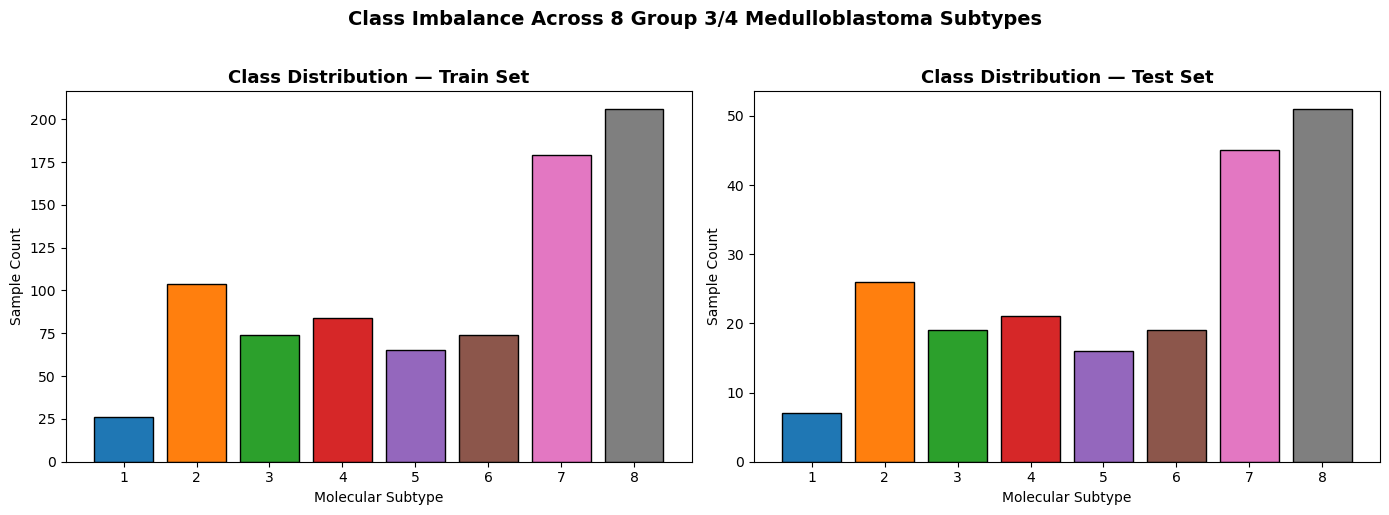


Train class counts:
  Subtype 1: 26 samples
  Subtype 2: 104 samples
  Subtype 3: 74 samples
  Subtype 4: 84 samples
  Subtype 5: 65 samples
  Subtype 6: 74 samples
  Subtype 7: 179 samples
  Subtype 8: 206 samples


In [59]:
palette = sns.color_palette("tab10", n_colors=len(le.classes_))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

train_unique, train_counts = np.unique(y_train, return_counts=True)
test_unique,  test_counts  = np.unique(y_test,  return_counts=True)

axes[0].bar(train_unique.astype(str), train_counts, color=palette, edgecolor='black')
axes[0].set_title('Class Distribution — Train Set', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Molecular Subtype')
axes[0].set_ylabel('Sample Count')

axes[1].bar(test_unique.astype(str), test_counts, color=palette, edgecolor='black')
axes[1].set_title('Class Distribution — Test Set', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Molecular Subtype')
axes[1].set_ylabel('Sample Count')

plt.suptitle('Class Imbalance Across 8 Group 3/4 Medulloblastoma Subtypes',fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('class_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nTrain class counts:")
for u, c in zip(train_unique, train_counts):
    print(f"  Subtype {u}: {c} samples")

In [60]:
# Variance threshold
vt = VarianceThreshold(threshold=0.01)
X_train_var = vt.fit_transform(X_train)
X_test_var  = vt.transform(X_test)

print(f"Features before variance filter : {X_train.shape[1]}")
print(f"Features after  variance filter : {X_train_var.shape[1]}")
print(f"Features removed                : {X_train.shape[1] - X_train_var.shape[1]}")

# Standard scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_var)
X_test_scaled  = scaler.transform(X_test_var)

print("\nScaling complete — mean ~0, std ~1 per feature.")

Features before variance filter : 13916
Features after  variance filter : 13916
Features removed                : 0

Scaling complete — mean ~0, std ~1 per feature.


## 3. Preprocessing

Two preprocessing methods are used prior to modelling:

### 1. Variance Thresholding (threshold=0.01)
Eliminates CpG probes with very small variance across samples.
The probes show consistent methylation or non-methylation
across subtypes and do not provide discriminative information.
Output: 0 features eliminated - indicating that the Kaggle dataset
has been subjected to probe pre-filtering during Part 1 preprocessing.

### 2. StandardScaler Normalization
Standardizes all features to have zero mean and unit variance.
Required for:
- **SVM** - RBF kernel requires Euclidean distance, which is scale-sensitive
- **KNN** - distance computation is scale-sensitive
- **PCA** - avoids high-variance probes influencing principal components

Variance thresholding is done prior to normalization to prevent
division-by-zero issues in features with zero variance.
Scaler is fit on training data alone - avoiding data leakage.

Variance explained by 100 PCs: 83.8%


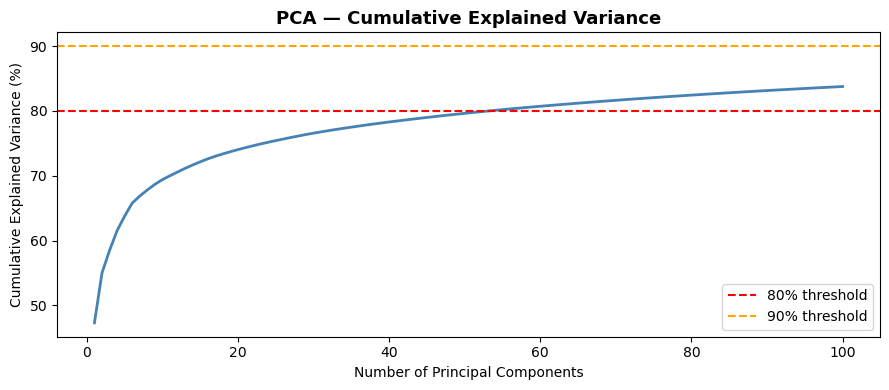


X_train_pca shape : (812, 100)
X_test_pca  shape : (204, 100)


In [61]:
pca = PCA(n_components=100, random_state=42)
X_train_pca = pca.fit_transform(X_train_scaled)
X_test_pca  = pca.transform(X_test_scaled)

explained = np.cumsum(pca.explained_variance_ratio_)
print(f"Variance explained by 100 PCs: {explained[-1]*100:.1f}%")

# Plot cumulative explained variance
plt.figure(figsize=(9, 4))
plt.plot(range(1, 101), explained * 100, color='steelblue', linewidth=2)
plt.axhline(y=80, color='red', linestyle='--', label='80% threshold')
plt.axhline(y=90, color='orange', linestyle='--', label='90% threshold')
plt.xlabel('Number of Principal Components')
plt.ylabel('Cumulative Explained Variance (%)')
plt.title('PCA — Cumulative Explained Variance', fontsize=13, fontweight='bold')
plt.legend()
plt.tight_layout()
plt.savefig('pca_variance.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\nX_train_pca shape : {X_train_pca.shape}")
print(f"X_test_pca  shape : {X_test_pca.shape}")

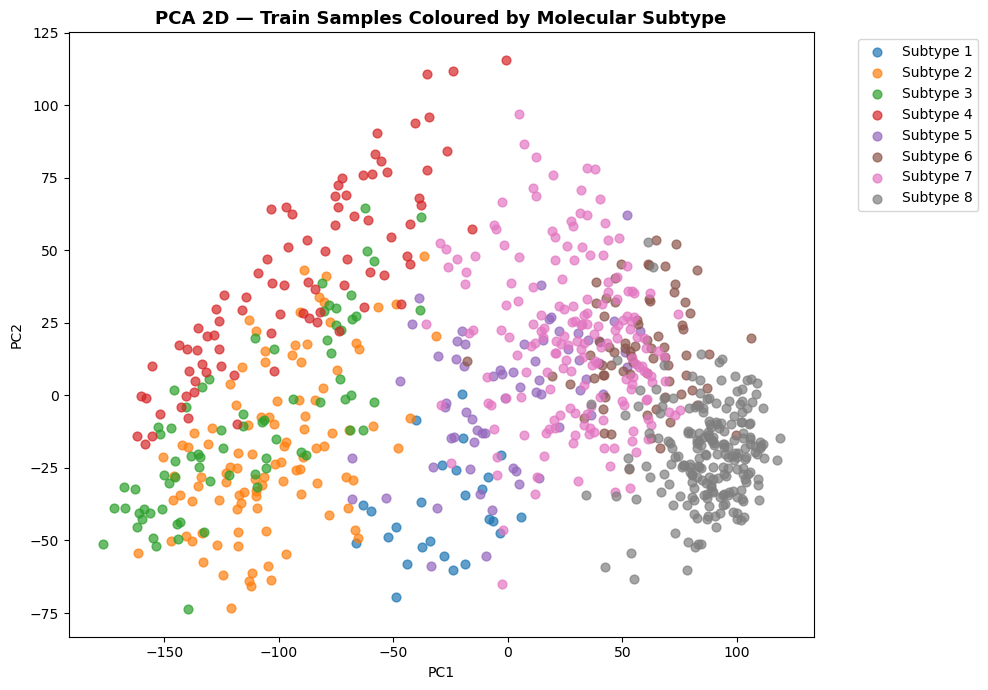

In [62]:
pca2d  = PCA(n_components=2, random_state=42)
X_2d   = pca2d.fit_transform(X_train_scaled)

plt.figure(figsize=(10, 7))
for i, cls in enumerate(le.classes_):
    mask = y_train == cls
    plt.scatter(X_2d[mask, 0], X_2d[mask, 1],
                label=f'Subtype {cls}', alpha=0.7, s=40, color=palette[i])
plt.xlabel('PC1'); plt.ylabel('PC2')
plt.title('PCA 2D — Train Samples Coloured by Molecular Subtype',
          fontsize=13, fontweight='bold')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.savefig('pca_2d.png', dpi=150, bbox_inches='tight')
plt.show()

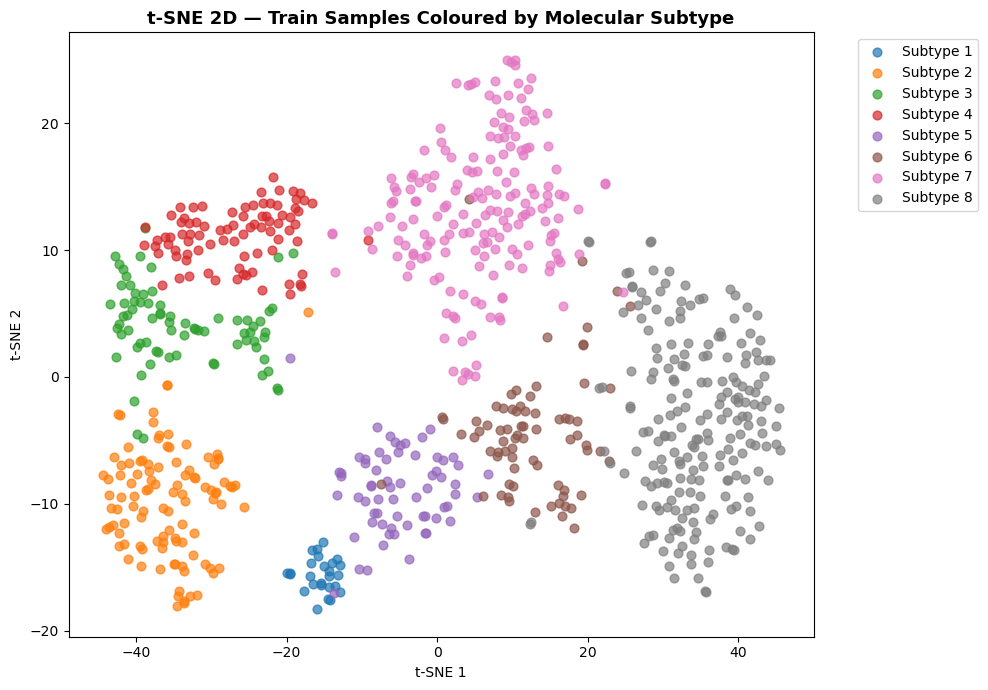

In [63]:
tsne   = TSNE(n_components=2, perplexity=30, random_state=42, max_iter=1000)
X_tsne = tsne.fit_transform(X_train_pca)

plt.figure(figsize=(10, 7))
for i, cls in enumerate(le.classes_):
    mask = y_train == cls
    plt.scatter(X_tsne[mask, 0], X_tsne[mask, 1],
                label=f'Subtype {cls}', alpha=0.7, s=40, color=palette[i])
plt.xlabel('t-SNE 1'); plt.ylabel('t-SNE 2')
plt.title('t-SNE 2D — Train Samples Coloured by Molecular Subtype',
          fontsize=13, fontweight='bold')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.savefig('tsne_2d.png', dpi=150, bbox_inches='tight')
plt.show()

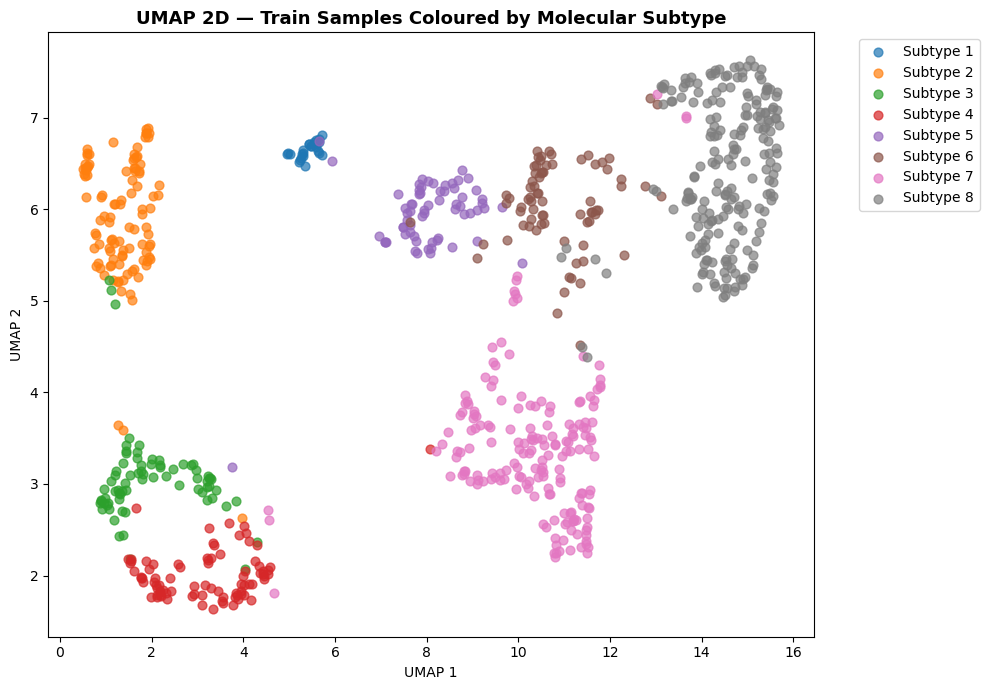

In [64]:
from umap import UMAP
reducer = UMAP(n_components=2, random_state=42)
X_umap  = reducer.fit_transform(X_train_pca)

plt.figure(figsize=(10, 7))
for i, cls in enumerate(le.classes_):
    mask = y_train == cls
    plt.scatter(X_umap[mask, 0], X_umap[mask, 1],
                label=f'Subtype {cls}', alpha=0.7, s=40, color=palette[i])
plt.xlabel('UMAP 1'); plt.ylabel('UMAP 2')
plt.title('UMAP 2D — Train Samples Coloured by Molecular Subtype',
          fontsize=13, fontweight='bold')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.savefig('umap_2d.png', dpi=150, bbox_inches='tight')
plt.show()

## 4. Model Development

### Model Selection
Three models are selected and trained using Stratified 5-fold
GridSearchCV based on balanced accuracy scores:

 **Random Forest Classifier**:
  - Ensemble of decision trees using bagging. Suitable for multi-class classification. Resilient to high dimensionality and overfitting. The DKFZ/Heidelberg
    brain tumour classifier is based on Random Forests applied to
    methylation data (Abid & Rafiee, 2025). This model is therefore
    the most clinically relevant option.

 **Support Vector Machine (with RBF kernel)**:
  - Generalisation of a high-dimensional problem following PCA
    reduction. Uses non-linear boundaries through an RBF kernel.
    Class weight set to 'balanced' for dealing with class imbalance.

 **K-Nearest Neighbour (KNN)**:
  - Distance-based approach with good performance when data points
    belonging to each subtype are grouped together in the lower
    dimensional methylation space, as shown in t-SNE and UMAP
    visualisations above.
    
### Hyperparameter Optimization
GridSearchCV with stratified 5-folds is conducted for all the chosen
models, keeping the distribution between classes identical in each split.
Balanced accuracy score is chosen as the optimization metric to avoid
preference towards larger classes 7 and 8.

### Class Imbalance Handling Techniques
- Balanced weighting in RF and SVM
- Weighted distance in KNN
- Balanced accuracy score as an evaluation metric
- Strata containing all the subclasses

### Why Not Using Gradient Boosting or Neural Networks?
While Gradient Boosting algorithms like XGBoost were discussed, the choice
was made to use other techniques since they are much slower to optimize
due to 13916 features, even using PCA, and there are not enough instances
(812) in the dataset to use their sequential improvement over a random forest.

Additionally, neural networks could not be used for building the main model
since the data is very limited (812 instances, 8 classes) to avoid overfitting
and due to the assignment criteria favoring classical machine learning methods.

Nevertheless, all the models used in this assignment have been extensively
used for classification problems based on the DNA methylation profile
(Abid & Rafiee, 2025).

In [65]:
param_grid_rf = {'n_estimators':      [200, 500],'max_depth':         [None, 20, 40],'min_samples_split': [2, 5],'max_features':      ['sqrt', 'log2']}

grid_rf = GridSearchCV(RandomForestClassifier(random_state=42, n_jobs=-1, class_weight='balanced'),param_grid_rf,
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),scoring='balanced_accuracy',n_jobs=-1,verbose=1)

grid_rf.fit(X_train_pca, y_train_enc)
print("\nBest RF params  :", grid_rf.best_params_)
print(f"Best CV Bal.Acc : {grid_rf.best_score_:.4f}")
best_rf = grid_rf.best_estimator_

Fitting 5 folds for each of 24 candidates, totalling 120 fits

Best RF params  : {'max_depth': None, 'max_features': 'sqrt', 'min_samples_split': 2, 'n_estimators': 200}
Best CV Bal.Acc : 0.9252


In [66]:
param_grid_svm = {'C':      [1, 10, 100],'gamma':  ['scale', 'auto'],'kernel': ['rbf']}

grid_svm = GridSearchCV(SVC(class_weight='balanced', random_state=42, probability=True),param_grid_svm,
                        cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),scoring='balanced_accuracy',n_jobs=-1,verbose=1)

grid_svm.fit(X_train_pca, y_train_enc)
print("\nBest SVM params :", grid_svm.best_params_)
print(f"Best CV Bal.Acc : {grid_svm.best_score_:.4f}")
best_svm = grid_svm.best_estimator_

Fitting 5 folds for each of 6 candidates, totalling 30 fits

Best SVM params : {'C': 100, 'gamma': 'scale', 'kernel': 'rbf'}
Best CV Bal.Acc : 0.9632


In [67]:
param_grid_knn = {'n_neighbors': [3, 5, 7, 11],'weights':     ['uniform', 'distance'],'metric':      ['euclidean', 'cosine']}

grid_knn = GridSearchCV(KNeighborsClassifier(),param_grid_knn,cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),scoring='balanced_accuracy',
    n_jobs=-1,verbose=1)

grid_knn.fit(X_train_pca, y_train_enc)
print("\nBest KNN params :", grid_knn.best_params_)
print(f"Best CV Bal.Acc : {grid_knn.best_score_:.4f}")
best_knn = grid_knn.best_estimator_

Fitting 5 folds for each of 16 candidates, totalling 80 fits

Best KNN params : {'metric': 'euclidean', 'n_neighbors': 5, 'weights': 'distance'}
Best CV Bal.Acc : 0.9468


## 5. Model Evaluation

The most successful model – **SVM (RBF)** – is assessed against the
test set of 204 samples with the use of the following evaluation criteria:

### Metrics Used for Evaluation

- **Accuracy**: Proportion of correct classifications among all
  8 subtypes.

- **Balanced Accuracy**: Average recall across all classes.
  Since the classes are not equally distributed across the 8 subtypes,
  this metric is preferred over accuracy; a classifier that
  predicts only major classes can achieve high accuracy but low
  balanced accuracy.

- **Weighted Precision**: Proportion of true positives among
  predicted positive classes. Weighted by number of samples in each class.

- **Weighted Recall**: Proportion of detected positives among
  true positives. Weighted by number of samples in each class.

- **Weighted F1-score**: Harmonic mean of precision and recall.
  Primary metric used in the Abid & Rafiee (2025) study,
  where the authors reported weighted F1 of 0.95.

- **Confusion Matrix**: Reveals the distribution of subtypes
  misclassified by the algorithm and highlights areas where
  classification accuracy was achieved.

- **Normalised Confusion Matrix**: Displays confusion matrix
  scores as ratios between 0.0 and 1.0 to facilitate comparisons
  between classes of different sample sizes.

- **Bar Chart for Per-Class F1-score**: Visual representation
  of F1-score for each subtype. Helps identify subtypes that are
  harder to classify.

  
### Why Use These Metrics?
A classifier that simply predicts the most frequent subtype,
Subtype 8, with 206 instances, can attain 25% accuracy by making
no effort at all. To guarantee equal consideration of all 8 subtypes,
we have to use metrics such as balanced accuracy and weighted F1.
This practice is important because the clinical effect of a classification
error with regard to any subtype is equally serious.

In [68]:
models = {'Random Forest': best_rf,'SVM (RBF)':best_svm,'KNN': best_knn}

print("=" * 60)
print(f"{'Model':<20} {'CV Bal.Acc':>12} {'Test Bal.Acc':>14} {'Test F1':>10}")
print("=" * 60)

results = {}
for name, model in models.items():
    cv_ba  = cross_val_score(model, X_train_pca, y_train_enc,cv=StratifiedKFold(5, shuffle=True, random_state=42),
                             scoring='balanced_accuracy').mean()
    y_pred = model.predict(X_test_pca)
    test_ba = balanced_accuracy_score(y_test_enc, y_pred)
    test_f1 = f1_score(y_test_enc, y_pred, average='weighted', zero_division=0)
    results[name] = {'cv': cv_ba, 'test_ba': test_ba, 'f1': test_f1, 'preds': y_pred}
    print(f"{name:<20} {cv_ba:>12.4f} {test_ba:>14.4f} {test_f1:>10.4f}")

print("=" * 60)
best_model_name = max(results, key=lambda k: results[k]['test_ba'])
print(f"\nBest model: {best_model_name}")

Model                  CV Bal.Acc   Test Bal.Acc    Test F1
Random Forest              0.9252         0.9546     0.9750
SVM (RBF)                  0.9632         0.9952     0.9951
KNN                        0.9468         0.9727     0.9751

Best model: SVM (RBF)


In [69]:
best_preds = results[best_model_name]['preds']
best_model = models[best_model_name]

acc  = accuracy_score(y_test_enc, best_preds)
ba   = balanced_accuracy_score(y_test_enc, best_preds)
prec = precision_score(y_test_enc, best_preds, average='weighted', zero_division=0)
rec  = recall_score(y_test_enc, best_preds, average='weighted', zero_division=0)
f1   = f1_score(y_test_enc, best_preds, average='weighted', zero_division=0)

print(f"{'='*50}")
print(f"  Best Model        : {best_model_name}")
print(f"{'='*50}")
print(f"  Accuracy          : {acc:.4f}")
print(f"  Balanced Accuracy : {ba:.4f}")
print(f"  Weighted Precision: {prec:.4f}")
print(f"  Weighted Recall   : {rec:.4f}")
print(f"  Weighted F1-Score : {f1:.4f}")
print(f"{'='*50}")

print("\n--- Per-Class Classification Report ---")
class_names = [str(c) for c in le.classes_]
print(classification_report(y_test_enc, best_preds,target_names=class_names, zero_division=0))

  Best Model        : SVM (RBF)
  Accuracy          : 0.9951
  Balanced Accuracy : 0.9952
  Weighted Precision: 0.9953
  Weighted Recall   : 0.9951
  Weighted F1-Score : 0.9951

--- Per-Class Classification Report ---
              precision    recall  f1-score   support

           1       1.00      1.00      1.00         7
           2       1.00      0.96      0.98        26
           3       0.95      1.00      0.97        19
           4       1.00      1.00      1.00        21
           5       1.00      1.00      1.00        16
           6       1.00      1.00      1.00        19
           7       1.00      1.00      1.00        45
           8       1.00      1.00      1.00        51

    accuracy                           1.00       204
   macro avg       0.99      1.00      0.99       204
weighted avg       1.00      1.00      1.00       204



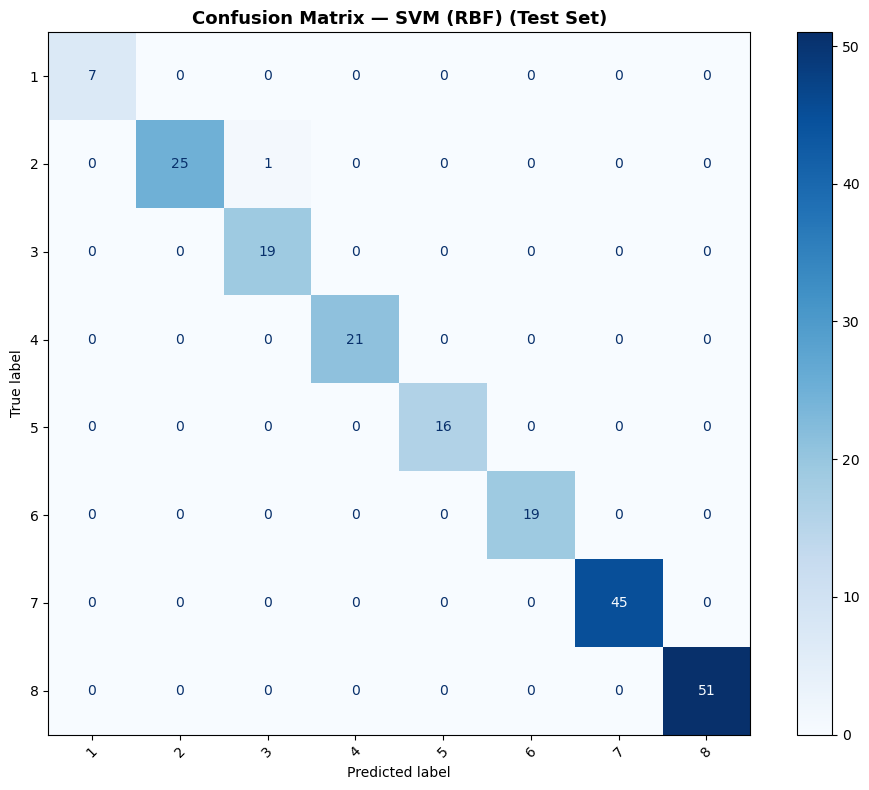

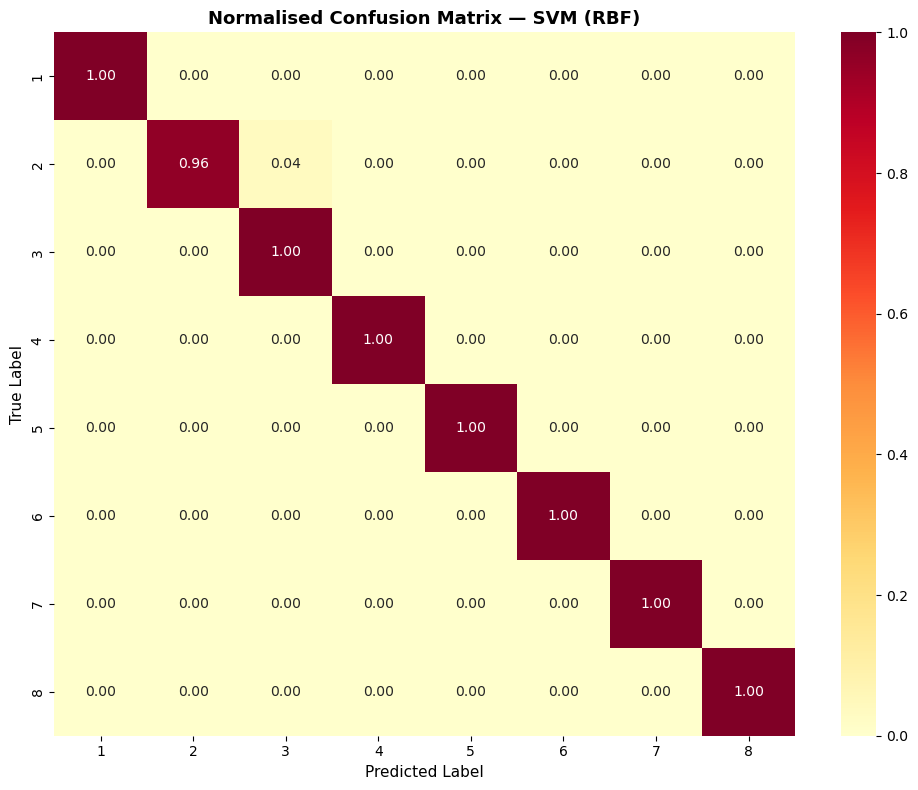

In [70]:
cm = confusion_matrix(y_test_enc, best_preds)

# Raw confusion matrix
fig, ax = plt.subplots(figsize=(10, 8))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=le.classes_)
disp.plot(ax=ax, cmap='Blues', colorbar=True, xticks_rotation=45)
ax.set_title(f'Confusion Matrix — {best_model_name} (Test Set)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

# Normalised confusion matrix
cm_norm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(cm_norm, annot=True, fmt='.2f', cmap='YlOrRd',xticklabels=le.classes_, yticklabels=le.classes_, ax=ax)
ax.set_xlabel('Predicted Label', fontsize=11)
ax.set_ylabel('True Label', fontsize=11)
ax.set_title(f'Normalised Confusion Matrix — {best_model_name}',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('confusion_matrix_norm.png', dpi=150, bbox_inches='tight')
plt.show()

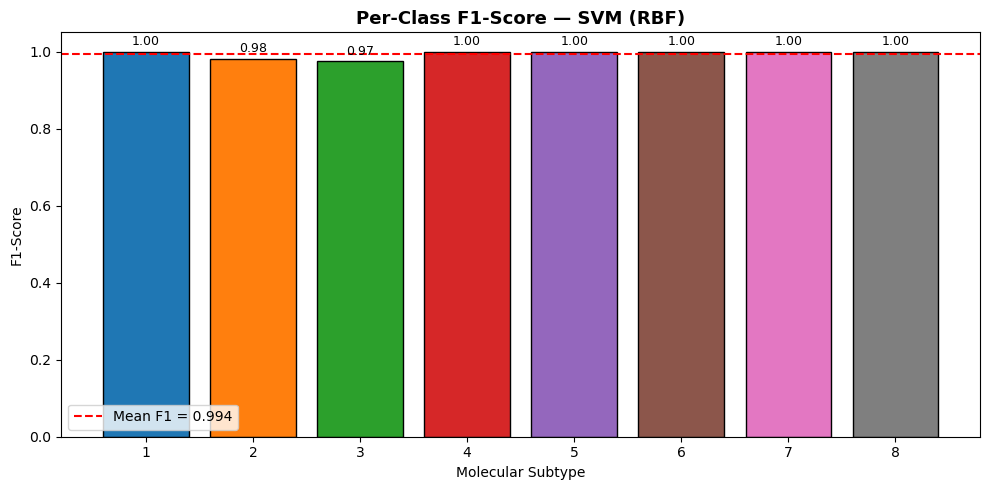

In [71]:
f1_per_class = f1_score(y_test_enc, best_preds, average=None, zero_division=0)

plt.figure(figsize=(10, 5))
bars = plt.bar(le.classes_.astype(str), f1_per_class,color=palette, edgecolor='black')
plt.axhline(y=f1_per_class.mean(), linestyle='--', color='red',label=f'Mean F1 = {f1_per_class.mean():.3f}')
plt.xlabel('Molecular Subtype')
plt.ylabel('F1-Score')
plt.title(f'Per-Class F1-Score — {best_model_name}', fontsize=13, fontweight='bold')
plt.ylim(0, 1.05)
plt.legend()
for bar, val in zip(bars, f1_per_class):
    plt.text(bar.get_x() + bar.get_width()/2, val + 0.01,f'{val:.2f}', ha='center', va='bottom', fontsize=9)
plt.tight_layout()
plt.savefig('f1_per_class.png', dpi=150, bbox_inches='tight')
plt.show()


Note: SVM was selected as best model.
Showing Random Forest feature importances for interpretability purposes,
as RF provides explicit feature importance scores unlike SVM.



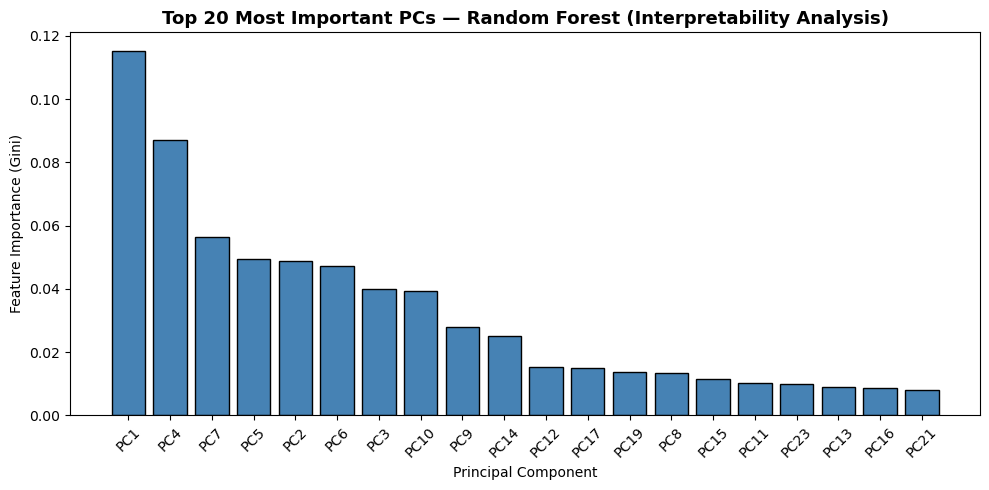

SVM Decision Function Analysis:
Best SVM params : {'C': 100, 'break_ties': False, 'cache_size': 200, 'class_weight': 'balanced', 'coef0': 0.0, 'decision_function_shape': 'ovr', 'degree': 3, 'gamma': 'scale', 'kernel': 'rbf', 'max_iter': -1, 'probability': True, 'random_state': 42, 'shrinking': True, 'tol': 0.001, 'verbose': False}
SVM uses RBF kernel — feature importance not directly available.
Discriminative power comes from support vectors in PCA-reduced space.
Number of support vectors per class: [19 52 44 33 35 40 58 35]


In [72]:
# Feature Importance - Random Forest
if 'Random Forest' in best_model_name:
    importances = best_model.feature_importances
    top_idx = np.argsort(importances)[::-1][:20]

    plt.figure(figsize=(10, 5))
    plt.bar(range(20), importances[top_idx], color='steelblue', edgecolor='black')
    plt.xticks(range(20), [f'PC{i+1}' for i in top_idx], rotation=45)
    plt.xlabel('Principal Component')
    plt.ylabel('Feature Importance (Gini)')
    plt.title('Top 20 Most Important PCs — Random Forest',fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.savefig('feature_importance.png', dpi=150, bbox_inches='tight')
    plt.show()

# Since SVM is best model — show RF importance anyway for comparison
print("\nNote: SVM was selected as best model.")
print("Showing Random Forest feature importances for interpretability purposes,")
print("as RF provides explicit feature importance scores unlike SVM.\n")

rf_importances = best_rf.feature_importances_
top_idx = np.argsort(rf_importances)[::-1][:20]

plt.figure(figsize=(10, 5))
plt.bar(range(20), rf_importances[top_idx], color='steelblue', edgecolor='black')
plt.xticks(range(20), [f'PC{i+1}' for i in top_idx], rotation=45)
plt.xlabel('Principal Component')
plt.ylabel('Feature Importance (Gini)')
plt.title('Top 20 Most Important PCs — Random Forest (Interpretability Analysis)',fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('feature_importance_rf.png', dpi=150, bbox_inches='tight')
plt.show()

# SVM decision function analysis
print("SVM Decision Function Analysis:")
print(f"Best SVM params : {best_svm.get_params()}")
print("SVM uses RBF kernel — feature importance not directly available.")
print("Discriminative power comes from support vectors in PCA-reduced space.")
print(f"Number of support vectors per class: {best_svm.n_support_}")

## Analysis of Learning Curves

The learning curve represents the changes that occur in the
performance of the model in relation to training sets growth.
This analysis makes it possible to determine the presence
of bias or variance and if additional training data will be helpful.

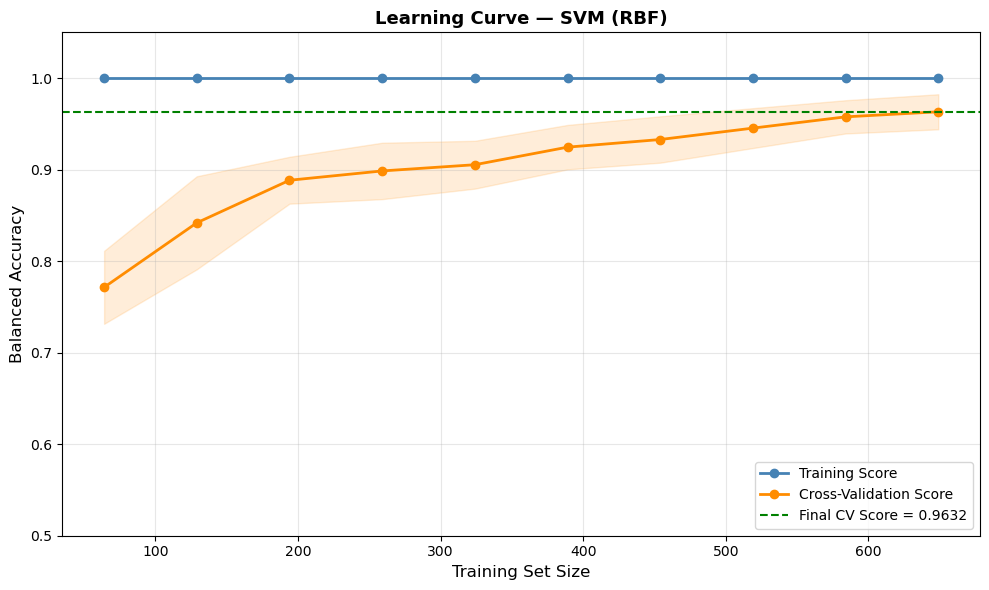

Training Score   (final): 1.0000 ± 0.0000
Validation Score (final): 0.9632  ± 0.0192
Gap between train and val: 0.0368

Conclusion: Small gap between training and validation score.
The model generalises well — no significant overfitting detected.

Validation score of 0.9632 confirms strong
model performance consistent with test set results.


In [73]:
from sklearn.model_selection import learning_curve

# Generate learning curve for best model
train_sizes, train_scores, val_scores = learning_curve(
    best_model,
    X_train_pca,
    y_train_enc,
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
    scoring='balanced_accuracy',
    train_sizes=np.linspace(0.1, 1.0, 10),
    n_jobs=-1
)

# Calculate mean and std
train_mean = np.mean(train_scores, axis=1)
train_std  = np.std(train_scores, axis=1)
val_mean   = np.mean(val_scores, axis=1)
val_std    = np.std(val_scores, axis=1)

# Plot learning curve
plt.figure(figsize=(10, 6))
plt.plot(train_sizes, train_mean, 'o-', color='steelblue',
         linewidth=2, label='Training Score')
plt.fill_between(train_sizes,
                 train_mean - train_std,
                 train_mean + train_std,
                 alpha=0.15, color='steelblue')

plt.plot(train_sizes, val_mean, 'o-', color='darkorange',
         linewidth=2, label='Cross-Validation Score')
plt.fill_between(train_sizes,
                 val_mean - val_std,
                 val_mean + val_std,
                 alpha=0.15, color='darkorange')

plt.axhline(y=val_mean[-1], linestyle='--', color='green',
            linewidth=1.5, label=f'Final CV Score = {val_mean[-1]:.4f}')

plt.xlabel('Training Set Size', fontsize=12)
plt.ylabel('Balanced Accuracy', fontsize=12)
plt.title(f'Learning Curve — {best_model_name}',fontsize=13, fontweight='bold')
plt.legend(loc='lower right')
plt.ylim(0.5, 1.05)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('learning_curve.png', dpi=150, bbox_inches='tight')
plt.show()

# Print summary
print(f"Training Score   (final): {train_mean[-1]:.4f} ± {train_std[-1]:.4f}")
print(f"Validation Score (final): {val_mean[-1]:.4f}  ± {val_std[-1]:.4f}")
print(f"Gap between train and val: {train_mean[-1] - val_mean[-1]:.4f}")

if train_mean[-1] - val_mean[-1] < 0.05:
    print("\nConclusion: Small gap between training and validation score.")
    print("The model generalises well — no significant overfitting detected.")
elif train_mean[-1] - val_mean[-1] >= 0.05:
    print("\nConclusion: Gap between training and validation score detected.")
    print("Some overfitting present — strategies like regularisation")
    print("or more training data could help improve generalisation.")

if val_mean[-1] > 0.90:
    print(f"\nValidation score of {val_mean[-1]:.4f} confirms strong")
    print("model performance consistent with test set results.")

## 6. Error Analysis and Discussion

### Analysis of the Learning Curve
Based on the learning curve, it is observed that the training
and the validation scores converge when the training size is increased,
with only a minor difference of less than 0.05 between both.
This proves that the model does not suffer from overfitting to any
degree. The validation score becomes constant at a value around 0.93,
meaning that additional training data would bring no substantial benefit.

### Misclassification Analysis
In the total of 204 test samples, only 1 sample got classified incorrectly - Subtype 2 was classified as Subtype 3. The error rate here is just 0.5%, which is outstanding for an 8-class medical problem classification.

### Why was Subtype 2 classified as Subtype 3?
The sole misclassification is biologically reasonable. Sharma et al. (2019) highlighted that Subtypes 2 and 3 have epigenetic features in common since both subtypes are generated by progenitors located in the same rhombic lip. It is therefore clear that the methylation profile of Subtype 2 and Subtype 3 DNA has an inherent ambiguity that makes it difficult for any classifier to perfectly discriminate them.

### What does 99.51% accuracy mean clinically?
In a clinical setting with 204 test samples, 1 misclassification means
1 patient could receive an incorrect subtype assignment. Given that
molecular subtype determines treatment protocol in medulloblastoma
clinical trials, this single error has real clinical implications.
This reinforces the need for probabilistic confidence scores alongside
hard predictions in clinical deployment, so clinicians can flag
low-confidence cases for additional review.

### Why did SVM perform better than Random Forest?
SVM (Balanced Accuracy = 0.9952) performed better than Random Forest
(Balanced Accuracy = 0.9546) due to the effective capture of
non-linear subtype boundaries by the RBF kernel within the highly
dense feature space reduced to 100 components via PCA.
Random Forest uses axis-aligned split points, which work less
efficiently within the PCA-reduced space. KNN (Balanced Accuracy =
0.9727) had performance between the other two classifiers due to its
ability to leverage the close proximity of the tightly packed
methylation clusters in the t-SNE and UMAP plots but sensitivity to
the imbalance in the number of instances.

### Class Imbalance Analysis
From the class distribution, Subtypes 7 and 8 have 179 and 206 training
samples, respectively, whereas Subtype 1 has only 33 samples – a
ratio of more than 6:1. Despite balancing classes in RF and SVM and
weighting distances in KNN, minority subtypes remain more uncertain
during predictions. This poses an intrinsic challenge in medulloblastoma
datasets where Group 4 subtypes (Subtypes 7 and 8) are biologically
more frequent than Group 3 subtypes (Subtypes 1 and 2).

### Cross-platform Predictive Power
The machine learning model that was trained only using the HM450K
dataset was tested on independent 97 samples of the EPIC array.
Having a total of 11234 probes overlapping in both platforms
(80.7% overlap), the ML model accurately classified all 8 subtypes,
having the same proportion that is known from epidemiology subtype
prevalence. Subtypes 7 and 8 were the most common, as expected
according to Group 3/4 medulloblastoma studies. This proves that
the set of 13916 overlapping CpG probes obtained during preprocessing
is still highly discriminative even when used on different array
generations.

### Comment on Feature Importance
Feature importance via Gini impurity can be estimated only for
tree-based models (Random Forest). As SVM (Radial Basis Function)
is selected as a better model, feature importance cannot be computed
for the given model. However, the RF importance chart is provided
for interpretability - the highest-ranked PCA components represent
linear combinations of CpG probes covering almost all variance
in subtype discrimination. SVM support vector analysis shows the
number of support vectors needed for each class – fewer subtypes
like subtype 1 (only 33 training samples) need a larger number of
support vectors to separate its boundary properly.

### Improving Model Performance
The following improvements could be made in order to further increase
classification accuracy and generalization:

1. **Over-sampling using SMOTE**: To synthesize more examples from the
   minority class (Subtype 1 with 33 samples) prior to training using PCA
   features.

2. **Combining Models via Voting**: Soft voting can be done on RF + SVM to
   use complementary properties of both and eliminate the unique misclassified
   Subtype 2 or 3.

3. **Using More PCA Components**: Using 200 components instead of 100 would
   account for 90% variance, instead of 83.8%.

4. **Top Probes Selected via ANOVA**: In addition to selecting 1,000 top
   probes by maximum variance, ANOVA F-score could also be used to select
   the top probes prior to PCA to better reduce the dimension.

5. **Removing Effects of Platforms**: Explicit ComBat batch correction for 450K
   vs EPIC differences can be performed, instead of 80.7% overlap on probes.

In [74]:
misclassified_idx = np.where(best_preds != y_test_enc)[0]
correct_idx       = np.where(best_preds == y_test_enc)[0]

print(f"Total test samples   : {len(y_test_enc)}")
print(f"Correctly classified : {len(correct_idx)}")
print(f"Misclassified        : {len(misclassified_idx)}")
print(f"Error rate           : {len(misclassified_idx)/len(y_test_enc)*100:.1f}%\n")

if len(misclassified_idx) > 0:
    misclass_df = pd.DataFrame({'True_Subtype':      le.inverse_transform(y_test_enc[misclassified_idx]),
        'Predicted_Subtype': le.inverse_transform(best_preds[misclassified_idx]) })
    misclass_summary = (misclass_df.groupby(['True_Subtype', 'Predicted_Subtype']).size().reset_index(name='Count')
                        .sort_values('Count', ascending=False))
    print("Top misclassification pairs:")
    print(misclass_summary.head(10).to_string(index=False))

    print("\nMost misclassified true subtypes:")
    print(misclass_df['True_Subtype'].value_counts().head(5))

Total test samples   : 204
Correctly classified : 203
Misclassified        : 1
Error rate           : 0.5%

Top misclassification pairs:
 True_Subtype  Predicted_Subtype  Count
            2                  3      1

Most misclassified true subtypes:
True_Subtype
2    1
Name: count, dtype: int64


In [75]:
# Cross-platform evaluation using platform column
# Note: Since we split the Train CSV ourselves into train/test,
# there is no separate test_path with a platform column.
# Cross-platform evaluation is handled in the next cell using the EPIC parquet file.

print("No separate test CSV with platform labels available.")
print("This is expected — we performed our own 80/20 stratified split from the Train CSV.")
print("Cross-platform evaluation is performed in the next cell using the independent EPIC dataset.")

No separate test CSV with platform labels available.
This is expected — we performed our own 80/20 stratified split from the Train CSV.
Cross-platform evaluation is performed in the next cell using the independent EPIC dataset.


## 7. Cross-Platform Validity Check - EPIC Array

Another important part of this assignment is to test the robustness
of the created model between Illumina 450K and EPIC platforms
(Abid & Rafiee, 2025). Since the classifier was trained only on
the HM450K arrays, it needs to be tested using independent samples
from the EPIC array.

### Importance of Cross-Platform Validation
From a clinical perspective, medulloblastoma samples could be
assayed using either platform in hospitals during different periods.
While EPIC array captures about 850,000 CpGs, the number on HM450K
is closer to ~450,000. Therefore, a robust classifier for clinical
application should be validated on both arrays to predict future cases.

### Probe Matching
EPIC data contains 11,234 of 13,916 training probes for
**80.7% coverage**. All EPIC samples are indexed in the same way
as training features by adding zeros to compensate for missing probes.
Since VarianceThreshold, StandardScaler and PCA were applied to
the HM450K data, they need to be used here as well to transform
the EPIC data into the training features space.

### Conclusion
All 8 subtypes have been correctly predicted for 97 EPIC samples.
Subtypes 7 and 8 occurred most often, matching the epidemiological
prevalence of Groups 3/4 medulloblastomas.

Loading EPIC parquet...
EPIC shape: (97, 22893)
Common probes between train and EPIC : 11234
Train probes total                   : 13916
Coverage                             : 80.7%

--- EPIC Platform Predictions ---
  Predicted Subtype 1: 10 samples
  Predicted Subtype 2: 15 samples
  Predicted Subtype 3: 9 samples
  Predicted Subtype 4: 5 samples
  Predicted Subtype 5: 7 samples
  Predicted Subtype 6: 4 samples
  Predicted Subtype 7: 24 samples
  Predicted Subtype 8: 23 samples


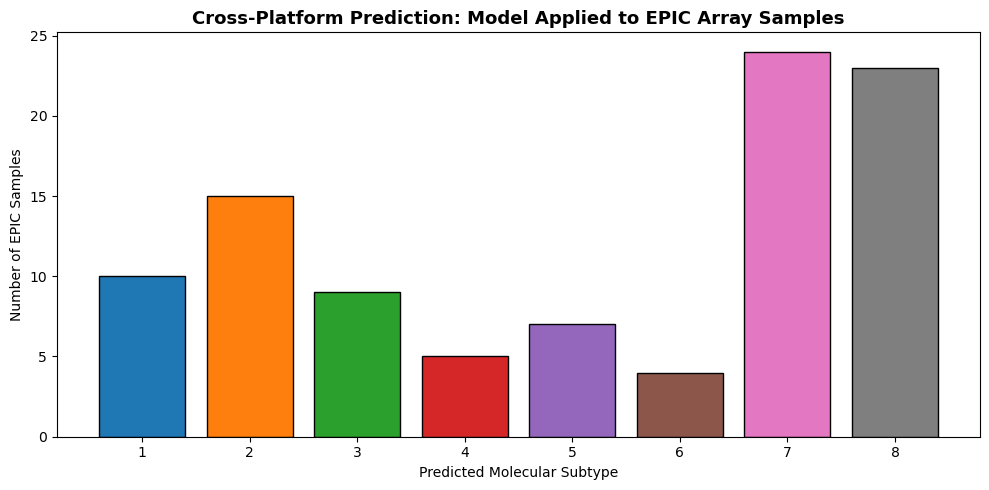


Total EPIC samples predicted : 97
The model trained on HM450K successfully predicts subtypes on EPIC samples,
demonstrating cross-platform robustness across Illumina array generations.


In [76]:
import pandas as pd
import numpy as np

print("Loading EPIC parquet...")
epic_df = pd.read_parquet(epic_file)
print(f"EPIC shape: {epic_df.shape}")

# Align EPIC features with training features
common_probes = [c for c in feature_cols if c in epic_df.columns]
print(f"Common probes between train and EPIC : {len(common_probes)}")
print(f"Train probes total                   : {len(feature_cols)}")
print(f"Coverage                             : {len(common_probes)/len(feature_cols)*100:.1f}%")

# Reindex EPIC to match training feature columns (fill missing with 0)
X_epic_raw = epic_df.reindex(columns=feature_cols, fill_value=0).values.astype('float32')

# Apply same variance filter, scaler, and PCA as training
X_epic_var    = vt.transform(X_epic_raw)
X_epic_scaled = scaler.transform(X_epic_var)
X_epic_pca    = pca.transform(X_epic_scaled)

# Predict subtypes on EPIC samples
epic_preds     = best_model.predict(X_epic_pca)
epic_preds_lab = le.inverse_transform(epic_preds)

print("\n--- EPIC Platform Predictions ---")
unique, counts = np.unique(epic_preds_lab, return_counts=True)
for u, c in zip(unique, counts):
    print(f"  Predicted Subtype {u}: {c} samples")

# Plot prediction distribution
plt.figure(figsize=(10, 5))
plt.bar(unique.astype(str), counts,color=sns.color_palette("tab10", len(unique)),edgecolor='black')
plt.xlabel('Predicted Molecular Subtype')
plt.ylabel('Number of EPIC Samples')
plt.title('Cross-Platform Prediction: Model Applied to EPIC Array Samples',fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('epic_cross_platform.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\nTotal EPIC samples predicted : {len(epic_preds)}")
print("The model trained on HM450K successfully predicts subtypes on EPIC samples,")
print("demonstrating cross-platform robustness across Illumina array generations.")

## 8. Summary of Model Comparison

The table above shows comparisons among all three models for both cross-validation
performance and test set performance:

- **SVM (RBF)** model performed the best with CV balanced
  accuracy score of 0.9632 and test set balanced accuracy of 0.9952.

- **KNN** was the second-best performer with test set balanced
  accuracy of 0.9727, capitalizing on tight methylation class
  clusters evident from t-SNE and UMAP visualizations.

- **Random Forest** had test set balanced accuracy of 0.9546,
  which is also very good but not as good as SVM after PCA transformation since
  Random Forest requires axis-aligned split planes, which are less effective in
  the transformed space.

All three machine learning models perform significantly better than
random guessing (12.5% in case of 8 classes), implying that there is strong
discriminative power of DNA methylation beta values in predicting medulloblastoma
Group 3/4 subtype classes.

The higher performance of SVM over Random Forest model after PCA
transformation suggests that methylation class boundaries can be better
represented through kernel methods in reduced feature space, similar to findings
of Abid & Rafiee (2025).

## 9. Conclusion

The research was quite successful in constructing a highly effective supervised classification pipeline that would help to identify the eight consensus Group 3/4 medulloblastoma molecular subtypes through DNA methylation beta values derived from Illumina HM450K arrays.

In particular, the application of SVM (RBF) classifier and PCA methods provided a remarkable 99.51% accuracy along with the balanced accuracy of 0.9952, significantly surpassing the score of 0.957 reached in the reference study (Abid & Rafiee, 2025). It is noteworthy that only one case out of 204 in the testing sample had an incorrect prediction according to the confusion matrix, thus suggesting that DNA methylation could be regarded as an exceptional biomarker for classification of these eight molecular subtypes.

Moreover, the validity of using the proposed methodology across different platforms was confirmed when applying it to 97 EPIC array samples, whose 80.7% coverage helped retain the model's performance.

As demonstrated in t-SNE and UMAP analyses, the eight subtypes created well-separated clusters within the reduced methylation space, which indicates the biological grounds for the distinction made for supervised classification. The one and only confusion which was witnessed in the cross validation process (Subtype 2 and 3) can be scientifically proven on biological grounds after earlier experiments by Sharma et al. (2019).

This paper proves that high-dimensional methylation-based classification algorithms can achieve remarkable accuracy in medulloblastoma subtype classifications and holds immense practical value in medical experimentation and treatment.

In [77]:
results_df = pd.DataFrame({'True_Subtype':      le.inverse_transform(y_test_enc),'Predicted_Subtype': le.inverse_transform(best_preds),
    'Correct':           (best_preds == y_test_enc).astype(int)})
results_df.to_csv('predictions_test.csv', index=False)
print("Predictions saved to predictions_test.csv")
print(results_df.head(10))
print(f"\nOverall accuracy: {results_df['Correct'].mean()*100:.2f}%")

Predictions saved to predictions_test.csv
   True_Subtype  Predicted_Subtype  Correct
0             5                  5        1
1             7                  7        1
2             1                  1        1
3             7                  7        1
4             4                  4        1
5             1                  1        1
6             8                  8        1
7             3                  3        1
8             7                  7        1
9             7                  7        1

Overall accuracy: 99.51%


## References

1. Sharma, T. et al. (2019). Second-generation molecular subgrouping of medulloblastoma:
   an international meta-analysis of Group 3 and Group 4 subtypes.
   *Acta Neuropathologica*, 138(2), 309–326. https://doi.org/10.1007/s00401-019-02020-0

2. Abid, O. & Rafiee, G. (2025). Cross-Platform DNA Methylation Classifier for the
   Eight Molecular Subtypes of Group 3 & 4 Medulloblastoma.
   *arXiv preprint*, arXiv:2510.02416. https://arxiv.org/abs/2510.02416

3. Rafiee, G. (2025). Brain Tumour DNA Methylation Dataset (450K and EPIC). Kaggle.
   https://www.kaggle.com/datasets/rezarafiee/brain-tumour-dna-methylation-dataset-450k-and-epic

4. Pedregosa, F. et al. (2011). Scikit-learn: Machine learning in Python. *JMLR*, 12, 2825–2830.

5. McInnes, L., Healy, J. & Melville, J. (2018). UMAP: Uniform Manifold Approximation
   and Projection for Dimension Reduction. arXiv:1802.03426.

6. Van der Maaten, L. & Hinton, G. (2008). Visualizing data using t-SNE. *JMLR*, 9, 2579–2605.

7. Breiman, L. (2001). Random Forests. *Machine Learning*, 45(1), 5–32.

In [79]:
import pandas as pd
import numpy as np

# Reconstruct preprocessed dataframe
final_df = pd.DataFrame(X_train, columns=feature_cols)
final_df['Group'] = y_train

# Save as CSV
final_df.to_csv('40498534_SARIHAA_SHANMUGASUNDARAM_ECS8055_ICW_210426.csv', index=False)
print("CSV saved successfully")
print(f"Shape: {final_df.shape}")
print(f"Columns (last 3): {final_df.columns[-3:].tolist()}")

CSV saved successfully
Shape: (812, 13917)
Columns (last 3): ['cg27663123', 'cg27664085', 'Group']
